In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('cleaned_data.csv')


In [5]:
# Check the first few rows
df.head()

,APA Tenant,HasPay,ActiveSubsidiaries,ActivatedModules,Sum of Employees,ActiveUsers,Industry,ERP,AP Automation,Sum of APA License utilization,...,AvgOverdueDays,AvgCommentsPerDocument,AvgTimeToCompleteTask,AvgCompletedTasksPerWeek,AvgLinesPerInvoice,DistinctLanguages,OverdueInvoiceCount,Sum of ACV (USD),TotalArchivedInvoices,Account Description
0,2xu,0,7,6,240.0,59,Retail,Apparel21,True,38.0,...,27.180712,1.710828,3.130565,787.203703,7.039703,2,1151,25680.10,5758,"Founded in Australia in 2005, 2XU is a technic..."
1,4cgroup,0,4,7,118.0,226,Professional Services,Visma Administration,True,45.0,...,16.271929,1.905237,1.357506,308.441860,1.375000,2,114,4111.88,1215,4C Strategies is a leading provider of organis...
2,aaacooper,0,3,7,6200.0,337,Logistics / Transportation,MS Dynamics AX,True,100.0,...,18.248596,1.916672,3.623532,24020.481480,1.584347,1,64132,144999.96,150053,"Founded in 1955, AAA Cooper Transportation, an..."
3,aaesbsp,0,15,7,151.0,445,Retail,Baan; Infor M3,True,45.0,...,21.380488,1.564303,1.088969,11403.462960,1.102656,5,12844,131655.44,53661,Portsystem AB is a company that operates in th...
4,aam,0,4,7,142.0,226,Manufacturing - Non-Durables,IFS,True,51.0,...,26.876218,1.623931,2.165624,6605.333333,2.511321,2,3692,57677.59,35750,Lamers High Tech Systems BV is a company that ...


C:\Users\AmnaSaied\AppData\Local\Temp\ipykernel_12964\3534281136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["HasPay"], palette=["#ff7f0e", "#1f77b4"])


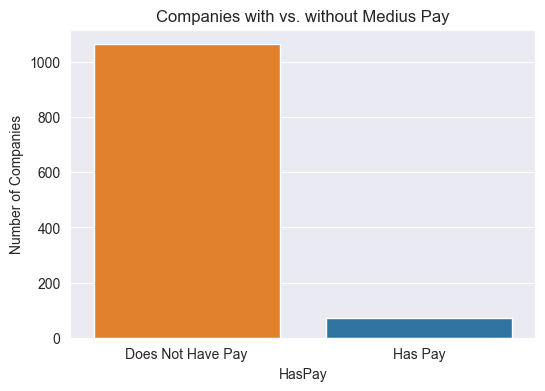

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=df["HasPay"], palette=["#ff7f0e", "#1f77b4"])
plt.xticks([0, 1], ["Does Not Have Pay", "Has Pay"])
plt.ylabel("Number of Companies")
plt.title("Companies with vs. without Medius Pay")
plt.show()



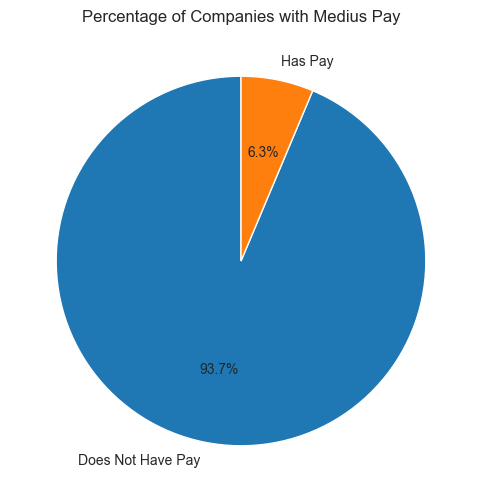

In [10]:
labels = ["Does Not Have Pay", "Has Pay"]
sizes = df["HasPay"].value_counts(normalize=True) * 100  # Convert to percentage
colors = ["#1f77b4", "#ff7f0e"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%.1f%%", colors=colors, startangle=90)
plt.title("Percentage of Companies with Medius Pay")
plt.show()


In [18]:
numeric_cols = df.select_dtypes(include=["number"]).columns  # Select only numeric columns
df[numeric_cols].groupby(df["HasPay"]).mean()
#spoting important areas for exploration:
#activeSubsidiaries
#Sum of employees
#AvrgInvoices


,HasPay,ActiveSubsidiaries,ActivatedModules,Sum of Employees,ActiveUsers,Sum of APA License utilization,Sum of Number of Locations,AvgInvoicesPerMonth,AvgOverdueDays,AvgCommentsPerDocument,AvgTimeToCompleteTask,AvgCompletedTasksPerWeek,AvgLinesPerInvoice,DistinctLanguages,OverdueInvoiceCount,Sum of ACV (USD),TotalArchivedInvoices
HasPay,,,,,,,,,,,,,,,,,
0,0.0,12.175917,7.909690,3720.946849,395.629351,66.639699,4.145814,3253.085458,24.580203,1.607850,1.860109,6705.334107,2.540571,2.413923,6104.037629,62165.472295,36805.660395
1,1.0,7.416667,10.819444,1350.708333,262.944444,64.416667,5.000000,2442.087771,27.223412,1.646624,1.683289,5247.981021,2.037132,1.611111,6854.166667,91296.885694,26730.083333


Distribution of active subsidiaries by haspay

C:\Users\AmnaSaied\AppData\Local\Temp\ipykernel_12964\201525751.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned']).size().reset_index(name='Count')


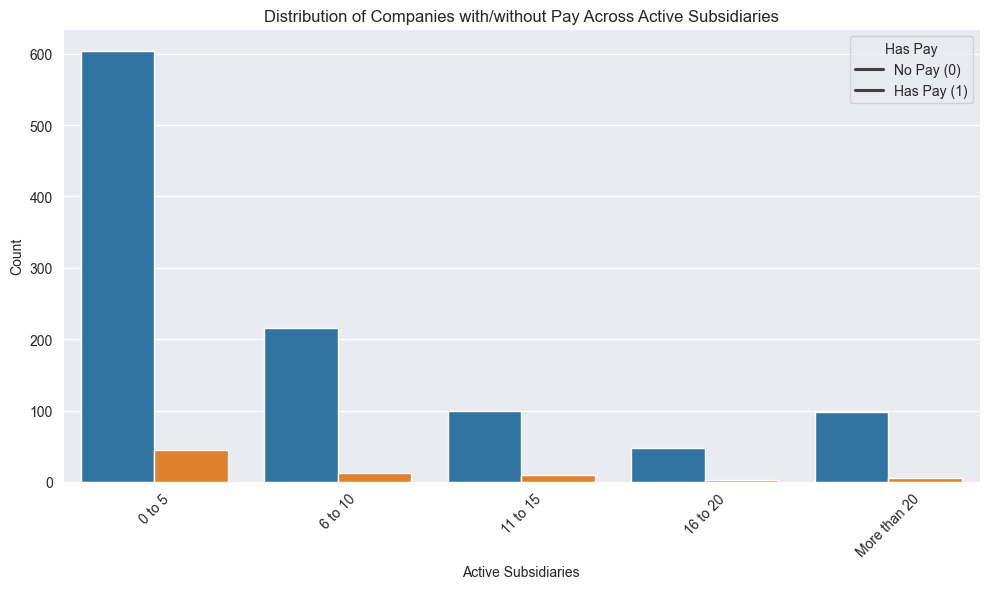

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the bins and labels for ActiveSubsidiaries
bins = [0, 5, 10, 15, 20, float('inf')]  # Defines the ranges
labels = ['0 to 5', '6 to 10', '11 to 15', '16 to 20', 'More than 20']

# Create a new column for binned ActiveSubsidiaries
df['ActiveSubsidiaries_Binned'] = pd.cut(df['ActiveSubsidiaries'], bins=bins, labels=labels, right=True)

# Group by 'HasPay' and the binned 'ActiveSubsidiaries'
df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned']).size().reset_index(name='Count')

# Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x='ActiveSubsidiaries_Binned', y='Count', hue='HasPay', data=df_grouped)

# Set chart title and labels
plt.title('Distribution of Companies with/without Pay Across Active Subsidiaries')
plt.xlabel('Active Subsidiaries')
plt.ylabel('Count')
plt.legend(title='Has Pay', labels=['No Pay (0)', 'Has Pay (1)'])

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




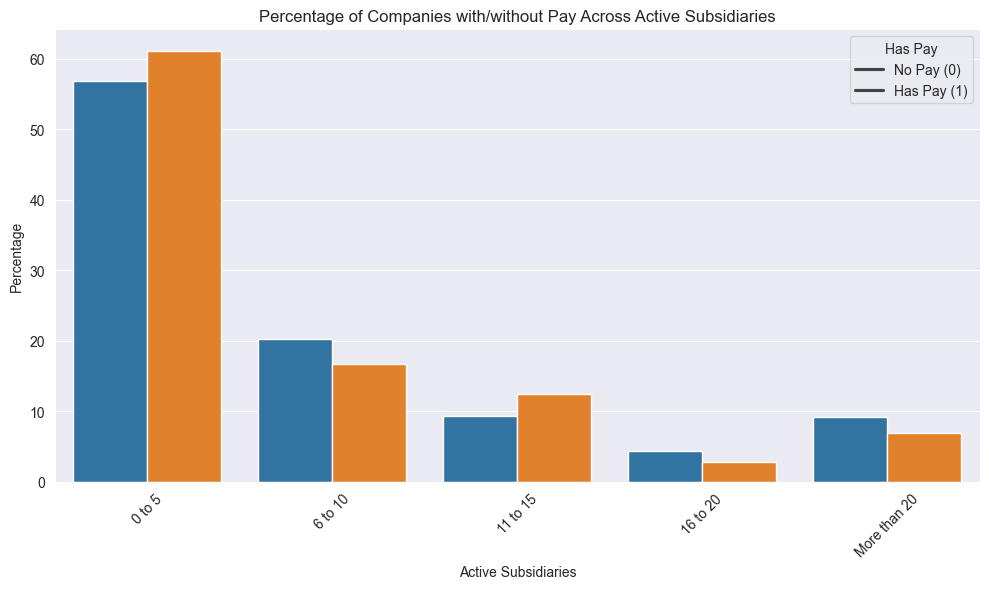

In [27]:
#% of pay companies out of total who have pay / same for not pay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the bins and labels for ActiveSubsidiaries
bins = [0, 5, 10, 15, 20, float('inf')]  # Defines the ranges
labels = ['0 to 5', '6 to 10', '11 to 15', '16 to 20', 'More than 20']


# Create a new column for binned ActiveSubsidiaries
df['ActiveSubsidiaries_Binned'] = pd.cut(df['ActiveSubsidiaries'], bins=bins, labels=labels, right=True)

# Group by 'HasPay' and the binned 'ActiveSubsidiaries'
df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned'], observed=False).size().reset_index(name='Count')


# Calculate the total number of companies in each HasPay group
total_has_pay = df_grouped[df_grouped['HasPay'] == 1]['Count'].sum()
total_no_pay = df_grouped[df_grouped['HasPay'] == 0]['Count'].sum()

# Calculate the percentage for each bin
df_grouped['Percentage'] = df_grouped.apply(lambda row: row['Count'] / total_has_pay * 100 if row['HasPay'] == 1 else row['Count'] / total_no_pay * 100, axis=1)

# Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x='ActiveSubsidiaries_Binned', y='Percentage', hue='HasPay', data=df_grouped)

# Set chart title and labels
plt.title('Percentage of Companies with/without Pay Across Active Subsidiaries')
plt.xlabel('Active Subsidiaries')
plt.ylabel('Percentage')
plt.legend(title='Has Pay', labels=['No Pay (0)', 'Has Pay (1)'])

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Set chart title and labels


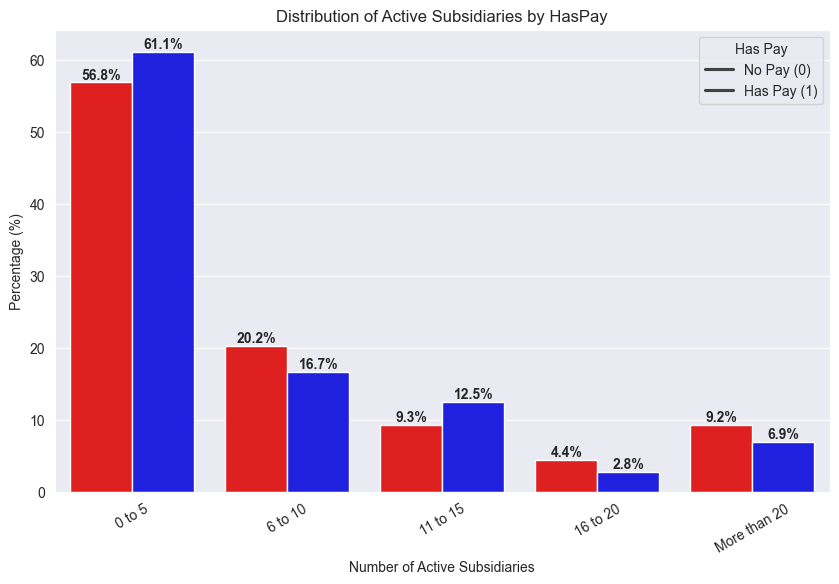

In [31]:
# Step 1: Define bins and labels
bins = [0, 5, 10, 15, 20, float('inf')]
labels = ['0 to 5', '6 to 10', '11 to 15', '16 to 20', 'More than 20']

# Step 2: Create the binned column
df['ActiveSubsidiaries_Binned'] = pd.cut(df['ActiveSubsidiaries'], bins=bins, labels=labels, right=True)

# Step 3: Count companies per bin, grouped by HasPay
df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned'], observed=False).size().reset_index(name='Count')

# Step 4: Fix index issue before calculating percentages
df_grouped['TotalPerGroup'] = df_grouped.groupby('HasPay')['Count'].transform('sum')

# Step 5: Calculate percentage within each HasPay category
df_grouped['Percentage'] = (df_grouped['Count'] / df_grouped['TotalPerGroup']) * 100

# Step 6: Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='ActiveSubsidiaries_Binned', y='Percentage', hue='HasPay', data=df_grouped,
            palette={0: 'red', 1: 'blue'})

# Step 7: Customize the plot
plt.xlabel("Number of Active Subsidiaries")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Active Subsidiaries by HasPay")
plt.legend(title="Has Pay", labels=["No Pay (0)", "Has Pay (1)"])
plt.xticks(rotation=30)

# Show values on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:  # Only label bars that have a value
        plt.text(p.get_x() + p.get_width() / 2, height + 0.5, f"{height:.1f}%",
                 ha='center', fontsize=10, fontweight='bold')

plt.show()
